# P8 - K-Means Clustering


Adapted from:
1) `https://github.com/probml/pyprobml/blob/master/notebooks/book1/21/kmeans_yeast_demo.ipynb`
2) Thomas Wedenig's Practical


Place the file yeastData310.npz in the same directory of where this file is

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn import datasets

/home/ancilli/miniforge3/envs/ml4ai_env/lib/python3.11/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.sparse import csr_matrix, issparse


In [2]:
def test_wcss(model, X):
    labels = model.predict(X) #predicts the closest cluster each sample in X belongs to 
    centers = model.cluster_centers_ # coordinate of the cluster centers
    diffs = X - centers[labels]
    return np.sum(diffs ** 2), labels

def plot_wcss(k_values, wcss_values):
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, wcss_values, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('WCSS on test')
    plt.title('Test WCSS vs k')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_silhouette(k_values, silhouette_score):
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, silhouette_score, 'bo-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score on test')
    plt.title('Test Silhouette vs k')
    plt.tight_layout()
    plt.show()

## Toy Dataset

In [3]:
n_samples = 10000
seed = 0
X = datasets.make_circles(
    n_samples = n_samples, 
    factor = 0.5, 
    noise = 0.05, 
    random_state = seed
)[0]

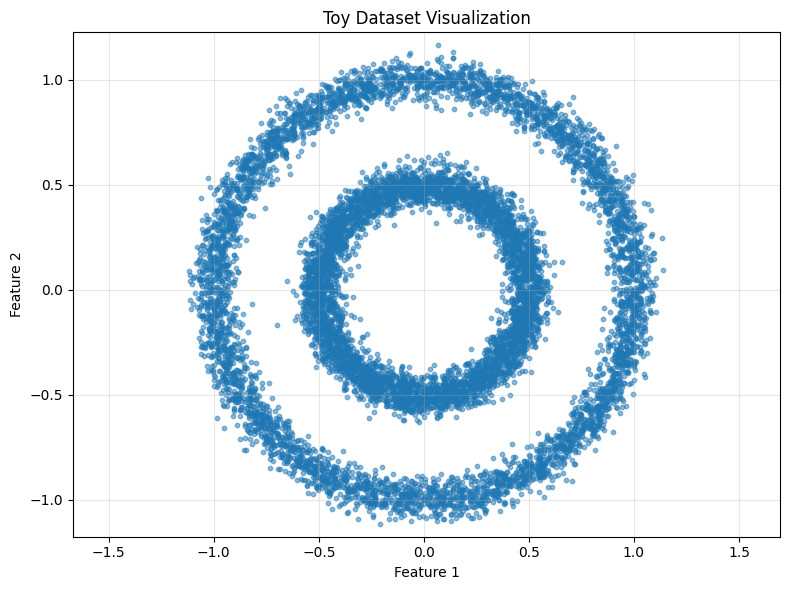

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Toy Dataset Visualization')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [5]:
X_train, X_test = train_test_split(X, test_size=0.2)
X_train.shape, X_test.shape

((8000, 2), (2000, 2))

In [ ]:
km = KMeans(
    n_clusters = 1,
    n_init = 10, # different initialization 
    random_state = 0, # set pseudo-random generator (reproducibility purpose), used to determined the initial cluster centroid
    algorithm ='lloyd', # kmeans algorithm 
    init = 'k-means++', #random, default is 'k-means++'
    )

km.fit(X_train) #compute k-means clustering

,n_clusters,1
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [7]:
cluster_counts = [2, 5, 10, 15, 20, 25, 30, 40, 50, 60, 100, 150, 200]
test_wcss_values = []
test_silhouette_scores = []
k_means_models = []

for k in cluster_counts:
    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0,
        algorithm='lloyd',
    )
    km.fit(X_train) 
    k_means_models.append(km)
    wcss, labels = test_wcss(km, X_test)
    test_wcss_values.append(wcss)
    test_silhouette_scores.append(silhouette_score(X_test, labels))

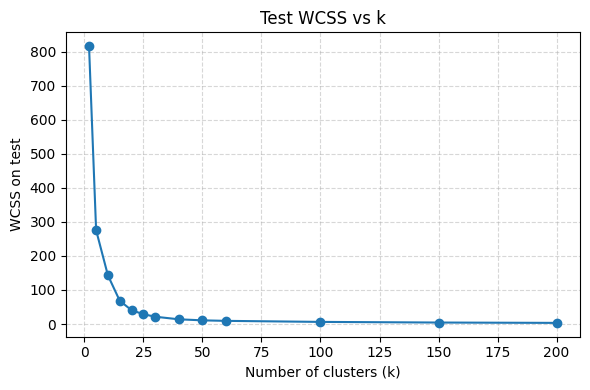

In [8]:
plot_wcss(cluster_counts, test_wcss_values)

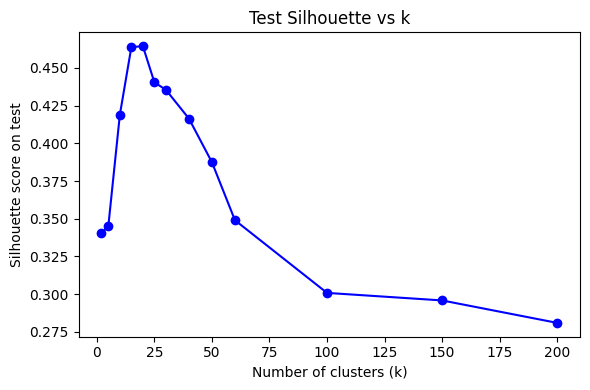

In [9]:
plot_silhouette(cluster_counts, test_silhouette_scores)

In [10]:
kmeans = KMeans(n_clusters=15, random_state=0, algorithm='lloyd', n_init=10)
kmeans.fit(X_train)
train_inertia = kmeans.inertia_
test_wcss, _ = test_wcss(kmeans, X_test)
print(f'Train WCSS: {train_inertia:.2f}')
print(f'Test WCSS: {test_wcss:.2f}')

Train WCSS: 265.25
Test WCSS: 68.42


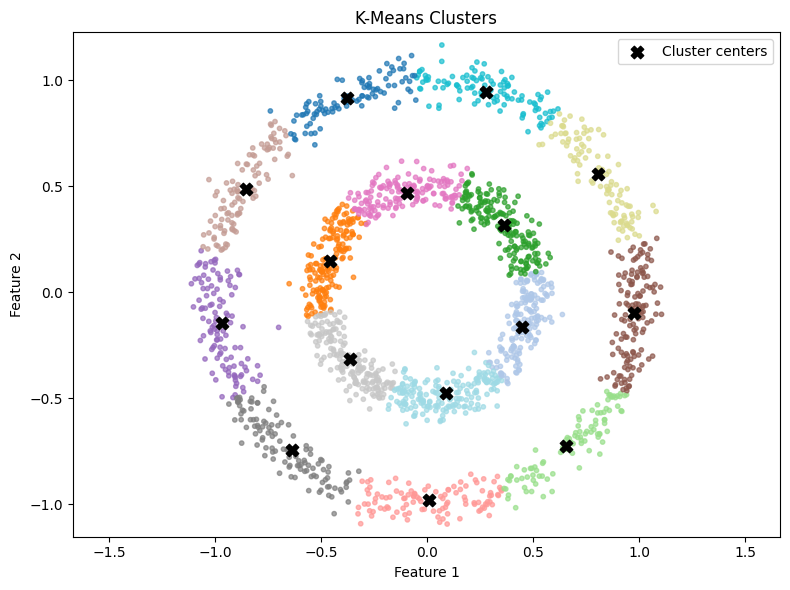

In [11]:
# Visualize K-Means clusters on the toy dataset
labels_all = kmeans.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=labels_all, cmap='tab20', s=10, alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='black',
    s=80,
    marker='X',
    label='Cluster centers'
)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clusters')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

## Visualize Time Series Data

In [12]:
npz = np.load('yeastData310.npz')
X_cells, times = npz['X'], npz['times']

In [13]:
X_cells.shape

(310, 7)

In [14]:
X_cells

array([[ 0.157,  0.175,  0.467, ..., -0.52 , -1.279, -2.125],
       [-0.235,  0.487, -0.184, ..., -1.006,  2.369,  2.611],
       [-0.532,  0.028, -0.333, ...,  1.172,  2.087,  0.992],
       ...,
       [ 0.074,  0.535,  1.603, ...,  1.58 ,  0.933,  2.044],
       [-0.195,  0.165, -0.333, ...,  0.858,  1.633,  3.028],
       [-0.247,  0.11 ,  0.042, ...,  1.07 ,  0.845,  2.328]],
      shape=(310, 7))

In [15]:
times

array([[ 0. ,  9.5, 11.5, 13.5, 15.5, 18.5, 20.5]])

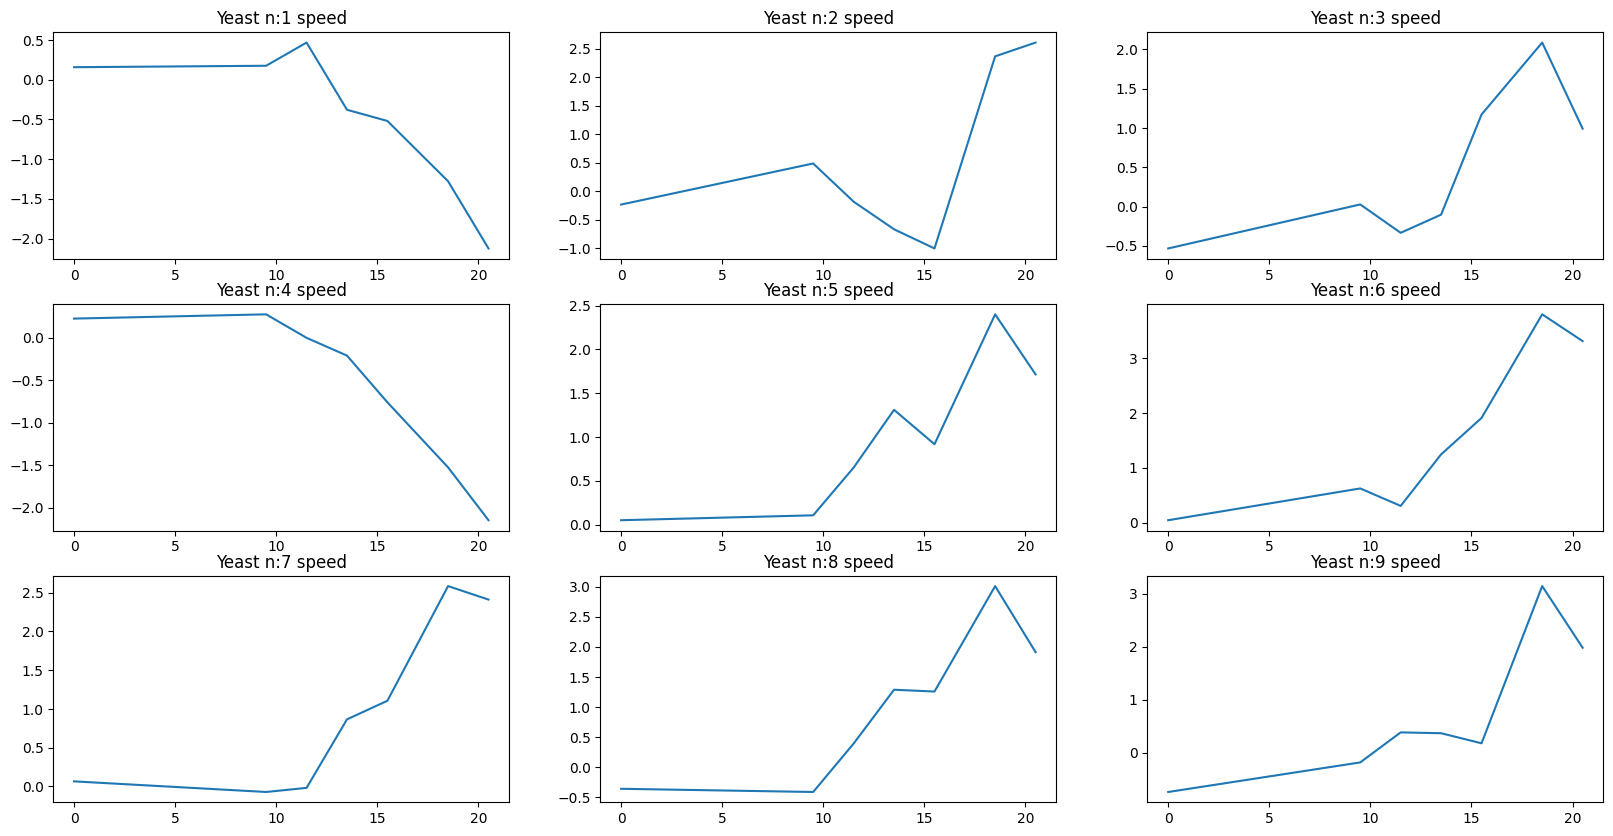

In [16]:
fig, axs = plt.subplots(3, 3, figsize=(20, 10))
axs = axs.reshape(-1)
for i in range(9):
    ax = axs[i]
    ax.plot(times.reshape(-1), X_cells[i, :].T)
    ax.set_title(f'Yeast n:{i+1} speed')

## Model Selection

In [17]:
cluster_counts = [2, 5, 10, 16, 20, 25, 30, 40, 50, 60, 100, 150, 200]
test_wcss_values_cells = []
k_means_models = []

for k in cluster_counts:
    
    km_ = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0,
        algorithm='lloyd',
    )

    km_.fit(X_cells)
    k_means_models.append(km_)

inertias = [model.inertia_ for model in k_means_models]


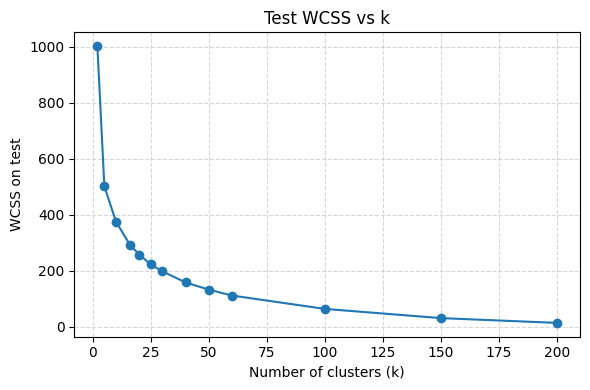

In [18]:
plot_wcss(cluster_counts, inertias)

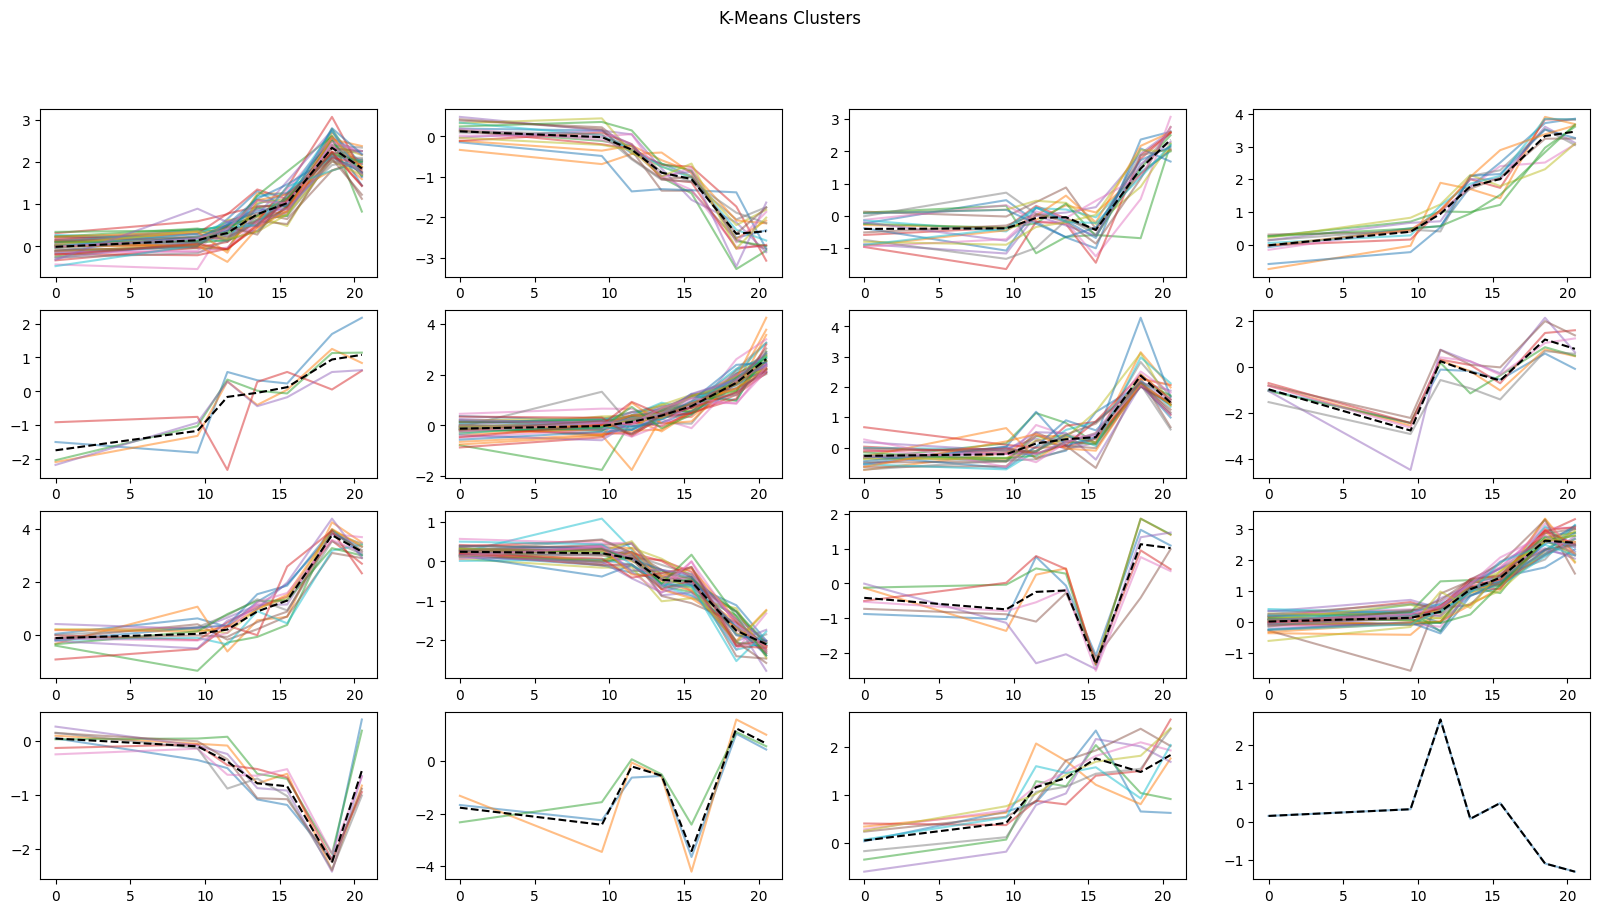

In [19]:
kmeans = KMeans(n_clusters=16, random_state=0, algorithm='lloyd', n_init=10)
kmeans.fit(X_cells)

labels = kmeans.labels_
clu_cen = kmeans.cluster_centers_
clusters = [[] for i in range(16)]

for (i, l) in enumerate(labels):
    clusters[l].append(i)

fig, axs = plt.subplots(4, 4, figsize=(20, 10))

axs = axs.reshape(-1)
for i in range(0, 16):
    ax = axs[i]
    if clusters[i] != []:
        ax.plot(times.reshape(-1), X_cells[clusters[i], :].T, alpha=0.5)
        # plot mean
        ax.plot(times.reshape(-1), clu_cen[i].T, 'k--')

plt.suptitle("K-Means Clusters")
plt.show()

In [20]:
for i in range(16):
    print(i, len(clusters[i]))

0 47
1 19
2 21
3 13
4 5
5 47
6 27
7 8
8 17
9 37
10 7
11 40
12 8
13 3
14 10
15 1
